## Parte I — 02. Análise Estatística

**Unidade Curricular:** Laboratório de Analise de Dados  
**Dataset:** NBA Stats (1947–2026)  

---

### Objetivos deste Notebook

Aplicar medidas estatísticas ao dataset consolidado para caracterizar e compreender as distribuições das variáveis:

1. Medidas de tendência central — média, mediana, moda
2. Medidas de dispersão — variância, desvio padrão
3. Covariância e correlações — relações entre variáveis
4. Tabelas resumo por posição — diferenças entre PG, SG, SF, PF, C
5. Tabelas resumo por era — evolução do jogo ao longo das décadas
6. Análise crítica — interpretação dos resultados

---
## Imports e Carregamento dos Dados

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Paths
OUTPUT_DIR = './outputs/'

# Estilo global dos gráficos
plt.rcParams.update({
    'figure.dpi'        : 120,
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : '#f8f8f8',
    'axes.grid'         : True,
    'grid.alpha'        : 0.4,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'font.family'       : 'sans-serif',
})
PALETTE = ['#C9082A', '#1D428A', '#FFC72C', '#007A33', '#552583']  # Cores NBA

df = pd.read_csv(f'{OUTPUT_DIR}dataset_nba.csv', low_memory=False)

print(f"Dataset carregado com sucesso!")
print(f"Dimensão: {df.shape[0]:,} registos × {df.shape[1]} colunas")
print(f"Épocas: {df['season'].min()} a {df['season'].max()}")
print(f"Jogadores: {df['player_id'].nunique():,} únicos")
print(f"\nColunas disponíveis:")
print([c for c in df.columns])

Dataset carregado com sucesso!
Dimensão: 30,987 registos × 56 colunas
Épocas: 1950 a 2026
Jogadores: 4,889 únicos

Colunas disponíveis:
['season', 'lg', 'player', 'player_id', 'age', 'team', 'pos', 'g', 'gs', 'mp_per_game', 'fg_per_game', 'fga_per_game', 'fg_percent', 'x3p_per_game', 'x3pa_per_game', 'x3p_percent', 'x2p_per_game', 'x2pa_per_game', 'x2p_percent', 'e_fg_percent', 'ft_per_game', 'fta_per_game', 'ft_percent', 'orb_per_game', 'drb_per_game', 'trb_per_game', 'ast_per_game', 'stl_per_game', 'blk_per_game', 'tov_per_game', 'pf_per_game', 'pts_per_game', 'per', 'ts_percent', 'usg_percent', 'ows', 'dws', 'ws', 'ws_48', 'obpm', 'dbpm', 'bpm', 'vorp', 'trp_dbl', 'birth_date', 'hof', 'from', 'to', 'colleges', 'experience', 'is_allstar', 'team_playoffs', 'height_cm', 'weight_kg', 'decade', 'is_nba']


In [84]:
# Definir colunas de trabalho

# Estatísticas base por jogo
STATS_BASE = [
    'pts_per_game', 'ast_per_game', 'trb_per_game',
    'stl_per_game', 'blk_per_game', 'tov_per_game',
    'mp_per_game',  'fg_percent',   'ft_percent'
]

# Métricas avançadas
STATS_ADV = ['per', 'ws', 'bpm', 'vorp', 'ts_percent', 'usg_percent']

# Todas as estatísticas numéricas relevantes juntas
STATS_ALL = STATS_BASE + STATS_ADV

# Filtrar só as que existem no dataset
STATS_BASE = [c for c in STATS_BASE if c in df.columns]
STATS_ADV  = [c for c in STATS_ADV  if c in df.columns]
STATS_ALL  = [c for c in STATS_ALL  if c in df.columns]

print(f"Estatísticas base: {STATS_BASE}")
print(f"Métricas avançadas: {STATS_ADV}")
print(f"Total de variáveis: {len(STATS_ALL)}")

Estatísticas base: ['pts_per_game', 'ast_per_game', 'trb_per_game', 'stl_per_game', 'blk_per_game', 'tov_per_game', 'mp_per_game', 'fg_percent', 'ft_percent']
Métricas avançadas: ['per', 'ws', 'bpm', 'vorp', 'ts_percent', 'usg_percent']
Total de variáveis: 15


---
## Medidas de Tendência Central

As medidas de tendência central descrevem o valor típico de uma variável:
- Média — soma de todos os valores dividida pelo número de observações. Sensível a outliers.
- Mediana — valor central quando os dados estão ordenados. Robusta a outliers.
- Moda — valor que aparece com mais frequência. Útil para variáveis discretas.

In [85]:
# Calcular média, mediana e moda para cada estatística 
tendencia = pd.DataFrame({
    'Média'   : df[STATS_ALL].mean(),
    'Mediana' : df[STATS_ALL].median(),
    'Moda'    : df[STATS_ALL].mode().iloc[0],  # iloc[0] porque pode haver mais do que uma moda
    'Std'     : df[STATS_ALL].std(),
}).round(3)

# Diferença entre média e mediana
tendencia['Média vs Mediana'] = (tendencia['Média'] - tendencia['Mediana']).round(3)

print("Medidas de tendência central — estatísticas NBA:\n")
tendencia.style \
    .format(precision=3) \
    .background_gradient(cmap='Blues', subset=['Média']) \
    .applymap(lambda v: 'color: #C9082A; font-weight: bold' if abs(v) > 1 else '',
              subset=['Média vs Mediana']) \
    .set_caption('Médias, medianas e modas das principais estatísticas NBA')

Medidas de tendência central — estatísticas NBA:



,Média,Mediana,Moda,Std,Média vs Mediana
pts_per_game,8.382,6.900,2.000,6.040,1.482
ast_per_game,1.910,1.400,0.500,1.781,0.510
trb_per_game,3.697,3.000,2.000,2.733,0.697
stl_per_game,0.663,0.600,0.300,0.462,0.063
blk_per_game,0.404,0.300,0.100,0.482,0.104
tov_per_game,1.223,1.000,0.800,0.816,0.223
mp_per_game,20.184,19.400,11.800,9.978,0.784
fg_percent,0.436,0.439,0.500,0.091,-0.003
ft_percent,0.726,0.749,1.000,0.137,-0.023
per,12.658,12.700,12.300,5.714,-0.042


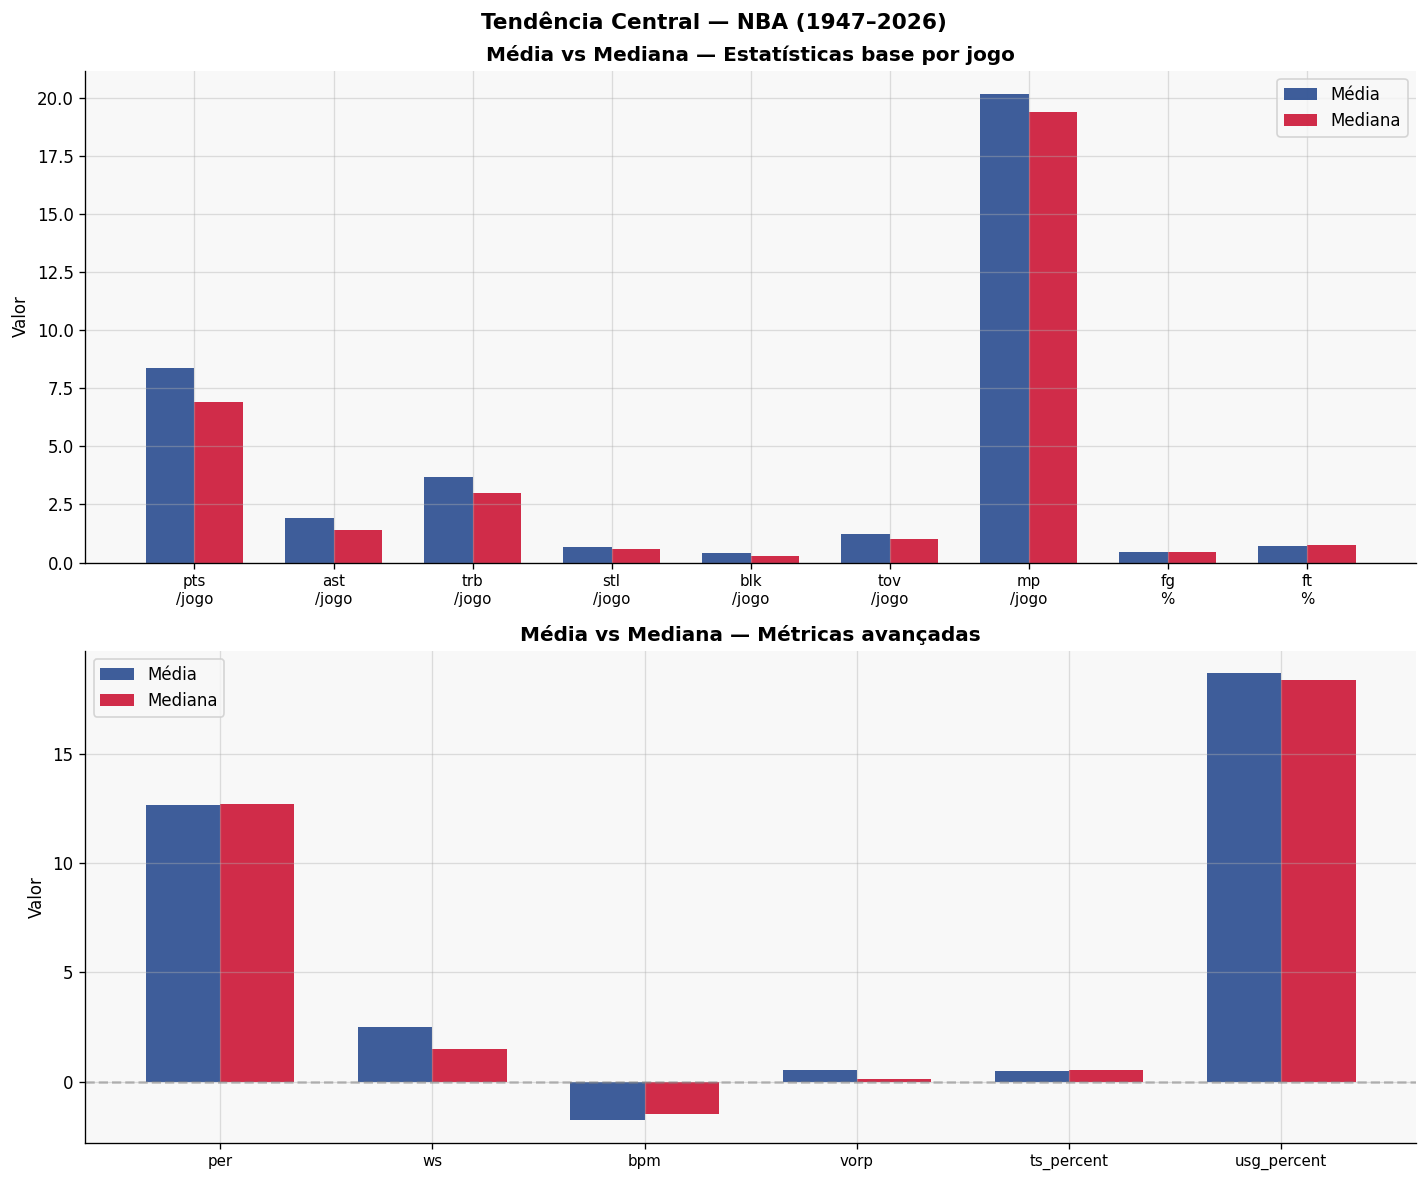

In [86]:
# Média vs Mediana 
# Quando a média > mediana, a distribuição é assimétrica à direita

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Estatísticas base
x = range(len(STATS_BASE))
width = 0.35

medias = [df[c].mean()   for c in STATS_BASE]
medianas = [df[c].median() for c in STATS_BASE]

bars1 = axes[0].bar([i - width/2 for i in x], medias, width, label='Média', color='#1D428A', alpha=0.85)
bars2 = axes[0].bar([i + width/2 for i in x], medianas, width, label='Mediana', color='#C9082A', alpha=0.85)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels([c.replace('_per_game', '\n/jogo').replace('_percent', '\n%') for c in STATS_BASE], fontsize=9)
axes[0].set_title('Média vs Mediana — Estatísticas base por jogo', fontweight='bold')
axes[0].set_ylabel('Valor')
axes[0].legend()

# Métricas avançadas
x2 = range(len(STATS_ADV))
medias2 = [df[c].mean()   for c in STATS_ADV]
medianas2 = [df[c].median() for c in STATS_ADV]

axes[1].bar([i - width/2 for i in x2], medias2, width, label='Média', color='#1D428A', alpha=0.85)
axes[1].bar([i + width/2 for i in x2], medianas2, width, label='Mediana', color='#C9082A', alpha=0.85)
axes[1].set_xticks(list(x2))
axes[1].set_xticklabels(STATS_ADV, fontsize=9)
axes[1].set_title('Média vs Mediana — Métricas avançadas', fontweight='bold')
axes[1].set_ylabel('Valor')
axes[1].legend()
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.suptitle('Tendência Central — NBA (1947–2026)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}02_tendencia_central.png', bbox_inches='tight')
plt.show()

In [87]:
# Resultados 

print("Medidas de Tendência Central") 
for col in STATS_ALL:
    media   = df[col].mean()
    mediana = df[col].median()
    diff    = media - mediana

    if abs(diff) > 1:
        direcao = "acima" if diff > 0 else "abaixo"
        print(f"  {col}: média {media:.2f} vs mediana {mediana:.2f} "
              f" - média {direcao} da mediana em {abs(diff):.2f} "
              f"(distribuição assimétrica)")
    else:
        print(f"  {col}: média {media:.2f} ≈ mediana {mediana:.2f} "
              f"(distribuição aproximadamente simétrica)")

Medidas de Tendência Central
  pts_per_game: média 8.38 vs mediana 6.90  - média acima da mediana em 1.48 (distribuição assimétrica)
  ast_per_game: média 1.91 ≈ mediana 1.40 (distribuição aproximadamente simétrica)
  trb_per_game: média 3.70 ≈ mediana 3.00 (distribuição aproximadamente simétrica)
  stl_per_game: média 0.66 ≈ mediana 0.60 (distribuição aproximadamente simétrica)
  blk_per_game: média 0.40 ≈ mediana 0.30 (distribuição aproximadamente simétrica)
  tov_per_game: média 1.22 ≈ mediana 1.00 (distribuição aproximadamente simétrica)
  mp_per_game: média 20.18 ≈ mediana 19.40 (distribuição aproximadamente simétrica)
  fg_percent: média 0.44 ≈ mediana 0.44 (distribuição aproximadamente simétrica)
  ft_percent: média 0.73 ≈ mediana 0.75 (distribuição aproximadamente simétrica)
  per: média 12.66 ≈ mediana 12.70 (distribuição aproximadamente simétrica)
  ws: média 2.49 ≈ mediana 1.50 (distribuição aproximadamente simétrica)
  bpm: média -1.77 ≈ mediana -1.50 (distribuição aproxima

---
## Medidas de Dispersão

As medidas de dispersão descrevem o grau de variabilidade dos dados em torno da tendência central:
- Variância — média dos desvios quadráticos em relação à média. Quanto maior, mais espalhados estão os dados.
- Desvio padrão — raiz quadrada da variância. Está na mesma unidade que os dados, mais fácil de interpretar.
- Coeficiente de variação (CV) — desvio padrão / média × 100. Permite comparar a dispersão entre variáveis com escalas diferentes.

In [88]:
# Calcular medidas de dispersão 
dispersao = pd.DataFrame({
    'Média'    : df[STATS_ALL].mean(),
    'Variância': df[STATS_ALL].var(),
    'Desvio Padrão': df[STATS_ALL].std(),
    'Mínimo'   : df[STATS_ALL].min(),
    'Máximo'   : df[STATS_ALL].max(),
    'Amplitude': df[STATS_ALL].max() - df[STATS_ALL].min(),
}).round(3)

# Coeficiente de variação — só faz sentido quando a média é positiva
dispersao['CV (%)'] = (dispersao['Desvio Padrão'] / dispersao['Média'].abs() * 100).round(1)

print("Medidas de dispersão — estatísticas NBA:\n")
dispersao.style \
    .format(precision=3) \
    .background_gradient(cmap='Reds', subset=['CV (%)']) \
    .set_caption('Variância, desvio padrão e coeficiente de variação')

Medidas de dispersão — estatísticas NBA:



,Média,Variância,Desvio Padrão,Mínimo,Máximo,Amplitude,CV (%)
pts_per_game,8.382,36.485,6.040,0.000,50.400,50.400,72.100
ast_per_game,1.910,3.172,1.781,0.000,14.500,14.500,93.200
trb_per_game,3.697,7.471,2.733,0.000,27.200,27.200,73.900
stl_per_game,0.663,0.214,0.462,0.000,3.700,3.700,69.700
blk_per_game,0.404,0.232,0.482,0.000,5.600,5.600,119.300
tov_per_game,1.223,0.666,0.816,0.000,5.700,5.700,66.700
mp_per_game,20.184,99.567,9.978,0.000,48.500,48.500,49.400
fg_percent,0.436,0.008,0.091,0.000,1.000,1.000,20.900
ft_percent,0.726,0.019,0.137,0.000,1.000,1.000,18.900
per,12.658,32.649,5.714,-90.600,133.800,224.400,45.100


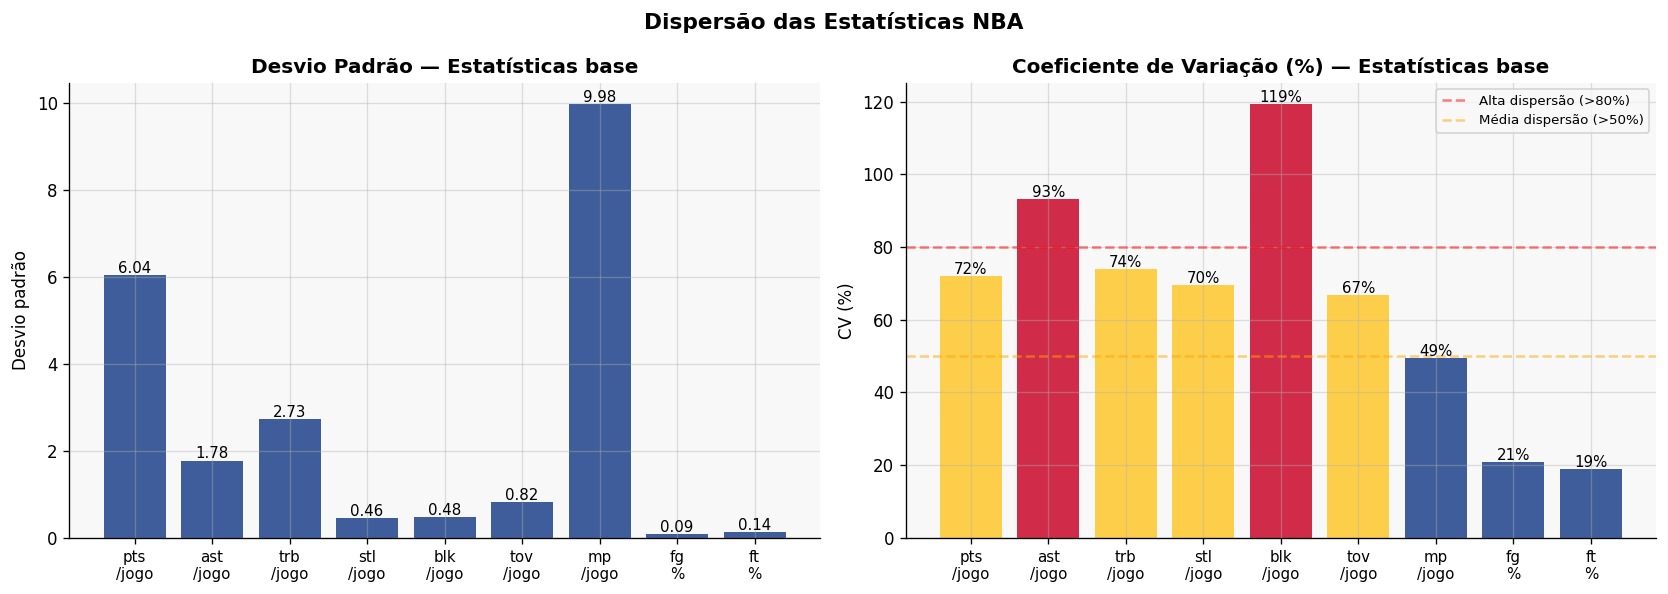

In [89]:
# Desvio Padrão por estatística 
# Um desvio padrão alto significa que há muita diferença entre jogadores

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Estatísticas base
std_base = [df[c].std() for c in STATS_BASE]
bars = axes[0].bar(range(len(STATS_BASE)), std_base, color=PALETTE[1], alpha=0.85)
axes[0].set_xticks(range(len(STATS_BASE)))
axes[0].set_xticklabels( [c.replace('_per_game','\n/jogo').replace('_percent','\n%') for c in STATS_BASE], fontsize=9)
axes[0].set_title('Desvio Padrão — Estatísticas base', fontweight='bold')
axes[0].set_ylabel('Desvio padrão')
for bar, val in zip(bars, std_base):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{val:.2f}', ha='center', fontsize=9)

# Coeficiente de variação 
cv_base = [(df[c].std() / abs(df[c].mean()) * 100) for c in STATS_BASE]
colors_cv = ['#C9082A' if v > 80 else '#FFC72C' if v > 50 else '#1D428A' for v in cv_base]
bars2 = axes[1].bar(range(len(STATS_BASE)), cv_base, color=colors_cv, alpha=0.85)
axes[1].set_xticks(range(len(STATS_BASE)))
axes[1].set_xticklabels( [c.replace('_per_game','\n/jogo').replace('_percent','\n%') for c in STATS_BASE], fontsize=9)
axes[1].set_title('Coeficiente de Variação (%) — Estatísticas base', fontweight='bold')
axes[1].set_ylabel('CV (%)')
axes[1].axhline(y=80, color='red', linestyle='--', alpha=0.5, label='Alta dispersão (>80%)')
axes[1].axhline(y=50, color='orange', linestyle='--', alpha=0.5, label='Média dispersão (>50%)')
axes[1].legend(fontsize=8)
for bar, val in zip(bars2, cv_base):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.0f}%', ha='center', fontsize=9)

plt.suptitle('Dispersão das Estatísticas NBA', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}02_dispersao.png', bbox_inches='tight')
plt.show()

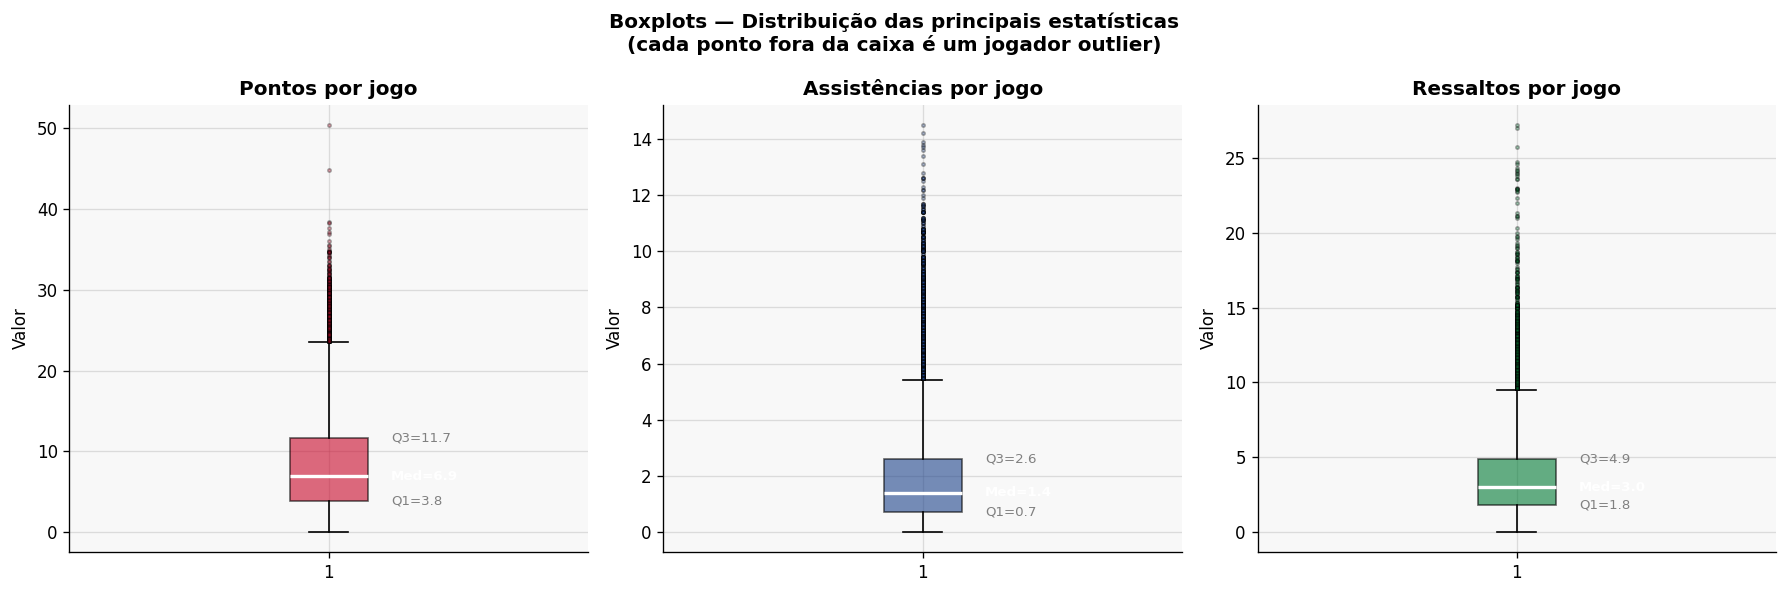

In [90]:
# Boxplots das estatísticas principais 

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

stats_boxplot = [
    ('pts_per_game', 'Pontos por jogo','#C9082A'),
    ('ast_per_game', 'Assistências por jogo','#1D428A'),
    ('trb_per_game', 'Ressaltos por jogo','#007A33'),
]

for ax, (col, titulo, cor) in zip(axes, stats_boxplot):
    data = df[col].dropna()
    bp = ax.boxplot(data, patch_artist=True,
                    boxprops=dict(facecolor=cor, alpha=0.6),
                    medianprops=dict(color='white', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor=cor,
                                   markersize=2, alpha=0.3))
    ax.set_title(titulo, fontweight='bold')
    ax.set_ylabel('Valor')

    # Anotar os valores-chave
    q1 = data.quantile(0.25)
    med = data.median()
    q3 = data.quantile(0.75)
    ax.text(1.12, q1, f'Q1={q1:.1f}', fontsize=8, va='center', color='gray')
    ax.text(1.12, med,f'Med={med:.1f}', fontsize=8, va='center', color='white',fontweight='bold')
    ax.text(1.12, q3, f'Q3={q3:.1f}', fontsize=8, va='center', color='gray')

plt.suptitle('Boxplots — Distribuição das principais estatísticas\n' '(cada ponto fora da caixa é um jogador outlier)', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}02_boxplots.png', bbox_inches='tight')
plt.show()

Apresentamos duas perspectivas complementares:
- Por época — identifica os recordes históricos numa única temporada
- Por carreira — calcula a média de todas as épocas, mais justa para comparar jogadores de eras diferentes

In [91]:
# Identificar os outliers — as maiores estrelas da história 
# Top 5 melhores épocas individuais 
print("TOP 5 — Melhores épocas individuais da história NBA\n")

tops_epoca = {
    'pts_per_game' : 'Pontos por jogo',
    'ast_per_game' : 'Assistências por jogo',
    'trb_per_game' : 'Ressaltos por jogo',
    'blk_per_game' : 'Blocos por jogo',
    'stl_per_game' : 'Roubos por jogo',
}

for col, nome in tops_epoca.items():
    if col not in df.columns:
        continue
    top5 = df.nlargest(5, col)[['player', 'season', col]]
    print(f"\n{nome}:")
    for _, row in top5.iterrows():
        print(f"  {row['player']:<25} {int(row['season'])}  {row[col]:.1f}")

# Top 10 melhores médias de carreira 
print("\n\nTOP 10 — Melhores médias de CARREIRA (todas as épocas combinadas)\n")

carreira = df.groupby('player')[['pts_per_game', 'ast_per_game']].mean().round(2)

print("\nPontos por jogo — média de carreira:")
top_pts = carreira['pts_per_game'].nlargest(10)
for i, (jogador, val) in enumerate(top_pts.items(), 1):
    print(f"  {i:2}. {jogador} {val:.1f} PPG")

print("\nAssistências por jogo — média de carreira:")
top_ast = carreira['ast_per_game'].nlargest(10)
for i, (jogador, val) in enumerate(top_ast.items(), 1):
    print(f"  {i:2}. {jogador} {val:.1f} APG")

TOP 5 — Melhores épocas individuais da história NBA


Pontos por jogo:
  Wilt Chamberlain          1962  50.4
  Wilt Chamberlain          1963  44.8
  Wilt Chamberlain          1961  38.4
  Elgin Baylor              1962  38.3
  Wilt Chamberlain          1960  37.6

Assistências por jogo:
  John Stockton             1990  14.5
  John Stockton             1991  14.2
  Isiah Thomas              1985  13.9
  John Stockton             1988  13.8
  John Stockton             1992  13.7

Ressaltos por jogo:
  Wilt Chamberlain          1961  27.2
  Wilt Chamberlain          1960  27.0
  Wilt Chamberlain          1962  25.7
  Bill Russell              1964  24.7
  Wilt Chamberlain          1966  24.6

Blocos por jogo:
  Mark Eaton                1985  5.6
  Manute Bol                1986  5.0
  Elmore Smith              1974  4.9
  Mark Eaton                1986  4.6
  Hakeem Olajuwon           1990  4.6

Roubos por jogo:
  Alvin Robertson           1986  3.7
  Don Buse                  1977  3

---
## Covariância e Correlações

A covariância e a correlação medem a relação linear entre duas variáveis:
- Covariância — indica se duas variáveis variam de forma positiva ou em sentidos opostos. Esta depende da escala dos dados.
- Correlação de Pearson — covariância normalizada, varia entre -1 e +1 e independentemente da escala é fácil de comparar.
  - +1 — correlação positiva perfeita (quando uma sobe, a outra sobe proporcionalmente)
  -  0 — sem correlação linear
  - -1 — correlação negativa perfeita (quando uma sobe, a outra desce proporcionalmente)

In [92]:
# Matriz de covariância 
cov_matrix = df[STATS_ALL].cov().round(3)

print("Matriz de Covariância:")
print(cov_matrix.iloc[:6, :6].to_string())

Matriz de Covariância:
              pts_per_game  ast_per_game  trb_per_game  stl_per_game  blk_per_game  tov_per_game
pts_per_game        36.485         6.858        10.302         1.849         0.972         4.065
ast_per_game         6.858         3.172         1.093         0.597        -0.001         1.122
trb_per_game        10.302         1.093         7.471         0.453         0.833         1.150
stl_per_game         1.849         0.597         0.453         0.214         0.038         0.260
blk_per_game         0.972        -0.001         0.833         0.038         0.232         0.120
tov_per_game         4.065         1.122         1.150         0.260         0.120         0.666


In [93]:
# Matriz de correlação de Pearson 
corr_matrix = df[STATS_ALL].corr(method='pearson').round(3)

print("Matriz de Correlação de Pearson:")
print(corr_matrix.to_string())

Matriz de Correlação de Pearson:
              pts_per_game  ast_per_game  trb_per_game  stl_per_game  blk_per_game  tov_per_game  mp_per_game  fg_percent  ft_percent    per     ws    bpm   vorp  ts_percent  usg_percent
pts_per_game         1.000         0.638         0.622         0.668         0.337         0.833        0.892       0.300       0.312  0.639  0.789  0.516  0.726       0.369        0.590
ast_per_game         0.638         1.000         0.224         0.716        -0.001         0.758        0.677       0.094       0.283  0.402  0.533  0.410  0.593       0.180        0.322
trb_per_game         0.622         0.224         1.000         0.391         0.688         0.569        0.686       0.337      -0.024  0.496  0.662  0.390  0.521       0.255        0.179
stl_per_game         0.668         0.716         0.391         1.000         0.171         0.697        0.745       0.151       0.221  0.447  0.603  0.476  0.621       0.209        0.263
blk_per_game         0.337      

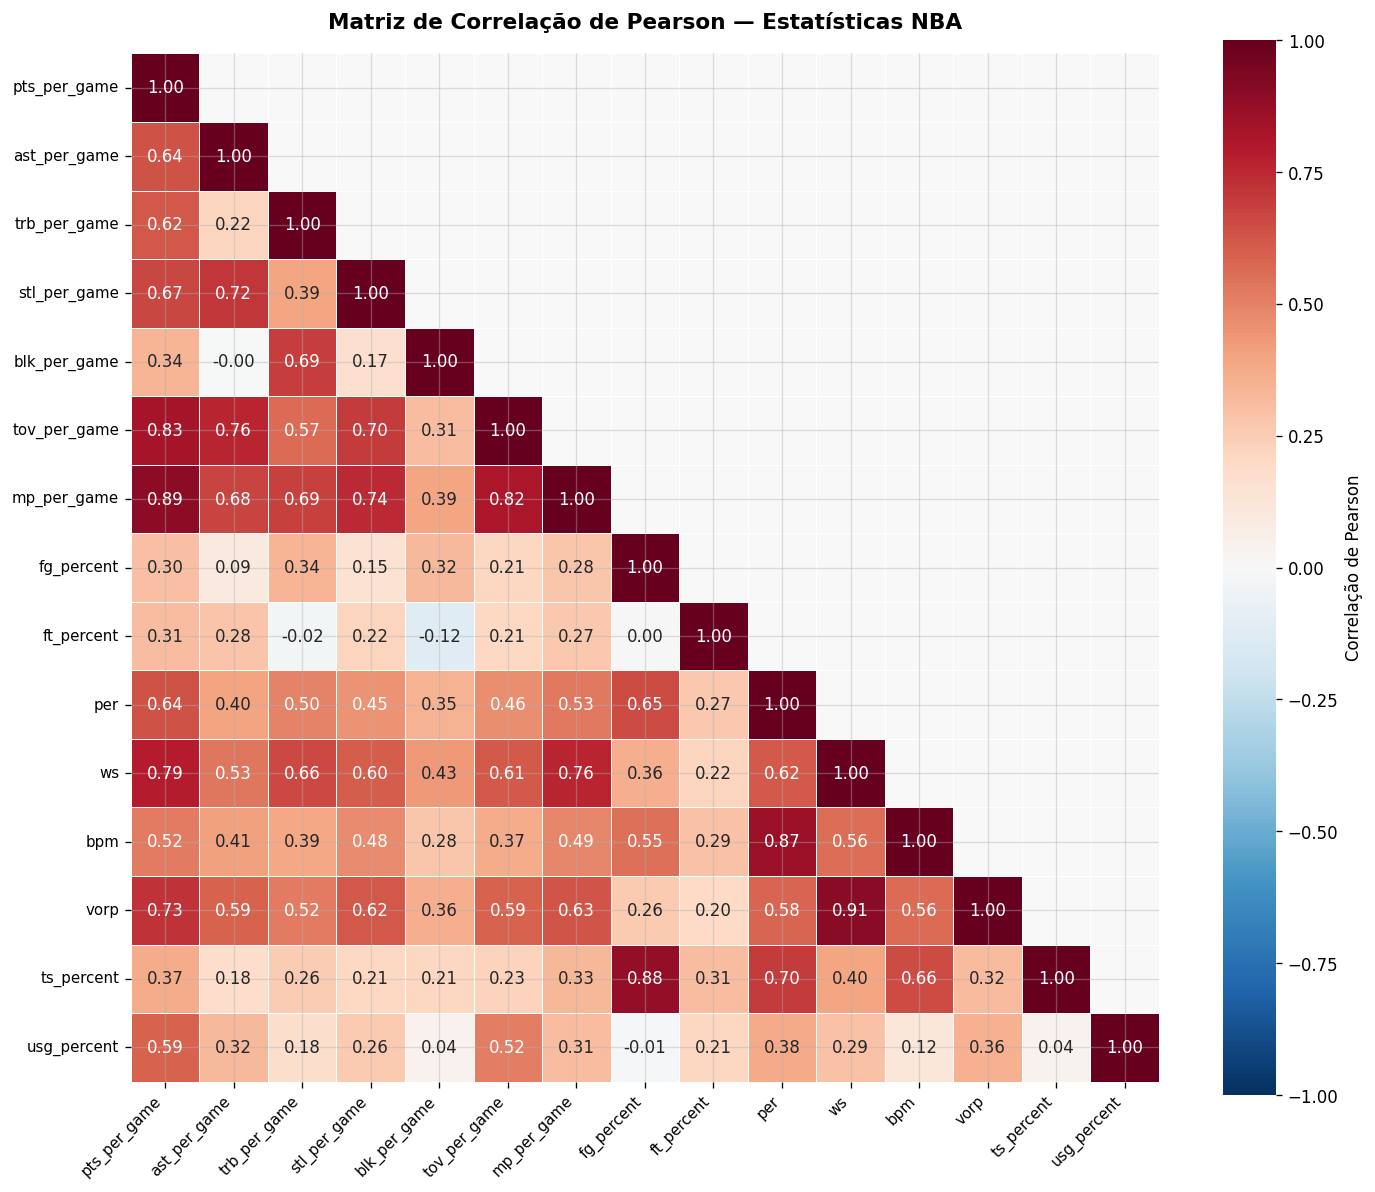

In [ ]:
# Heatmap da matriz de correlação, O heatmap é a forma visual mais clara de apresentar correlações
# Azul escuro = correlação positiva forte
# Vermelho escuro = correlação negativa forte
# Branco = sem correlação

fig, ax = plt.subplots(figsize=(12, 10))

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True  

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,           # Mostrar valores numéricos
    fmt='.2f',           
    cmap='RdBu_r',        # Vermelho-Branco-Azul
    vmin=-1, vmax=1,      
    center=0,             
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Correlação de Pearson'}
)

ax.set_title('Matriz de Correlação de Pearson — Estatísticas NBA', fontweight='bold', fontsize=13, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}02_correlacoes_heatmap.png', bbox_inches='tight')
plt.show()

In [95]:
# Correlações mais fortes 
# Extrair os pares de variáveis com correlação mais alta 
corr_pairs = corr_matrix.where(
    np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool)
).stack().reset_index()
corr_pairs.columns = ['Var1', 'Var2', 'Correlação']
corr_pairs['Abs'] = corr_pairs['Correlação'].abs()
corr_pairs = corr_pairs.sort_values('Abs', ascending=False)

print("TOP 10 — Correlações mais fortes:")
print(corr_pairs.head(10)[['Var1', 'Var2', 'Correlação']].to_string(index=False))

print("\nTOP 5 — Correlações mais fracas:")
print(corr_pairs.tail(5)[['Var1', 'Var2', 'Correlação']].to_string(index=False))

TOP 10 — Correlações mais fortes:
-------------------------------------------------------
        Var1         Var2  Correlação
        vorp           ws       0.906
 mp_per_game pts_per_game       0.892
  ts_percent   fg_percent       0.879
         bpm          per       0.867
tov_per_game pts_per_game       0.833
 mp_per_game tov_per_game       0.816
          ws pts_per_game       0.789
          ws  mp_per_game       0.764
tov_per_game ast_per_game       0.758
 mp_per_game stl_per_game       0.745

TOP 5 — Correlações mais fracas:
-------------------------------------------------------
        Var1         Var2  Correlação
 usg_percent   ts_percent       0.039
  ft_percent trb_per_game      -0.024
 usg_percent   fg_percent      -0.008
blk_per_game ast_per_game      -0.001
  ft_percent   fg_percent       0.001


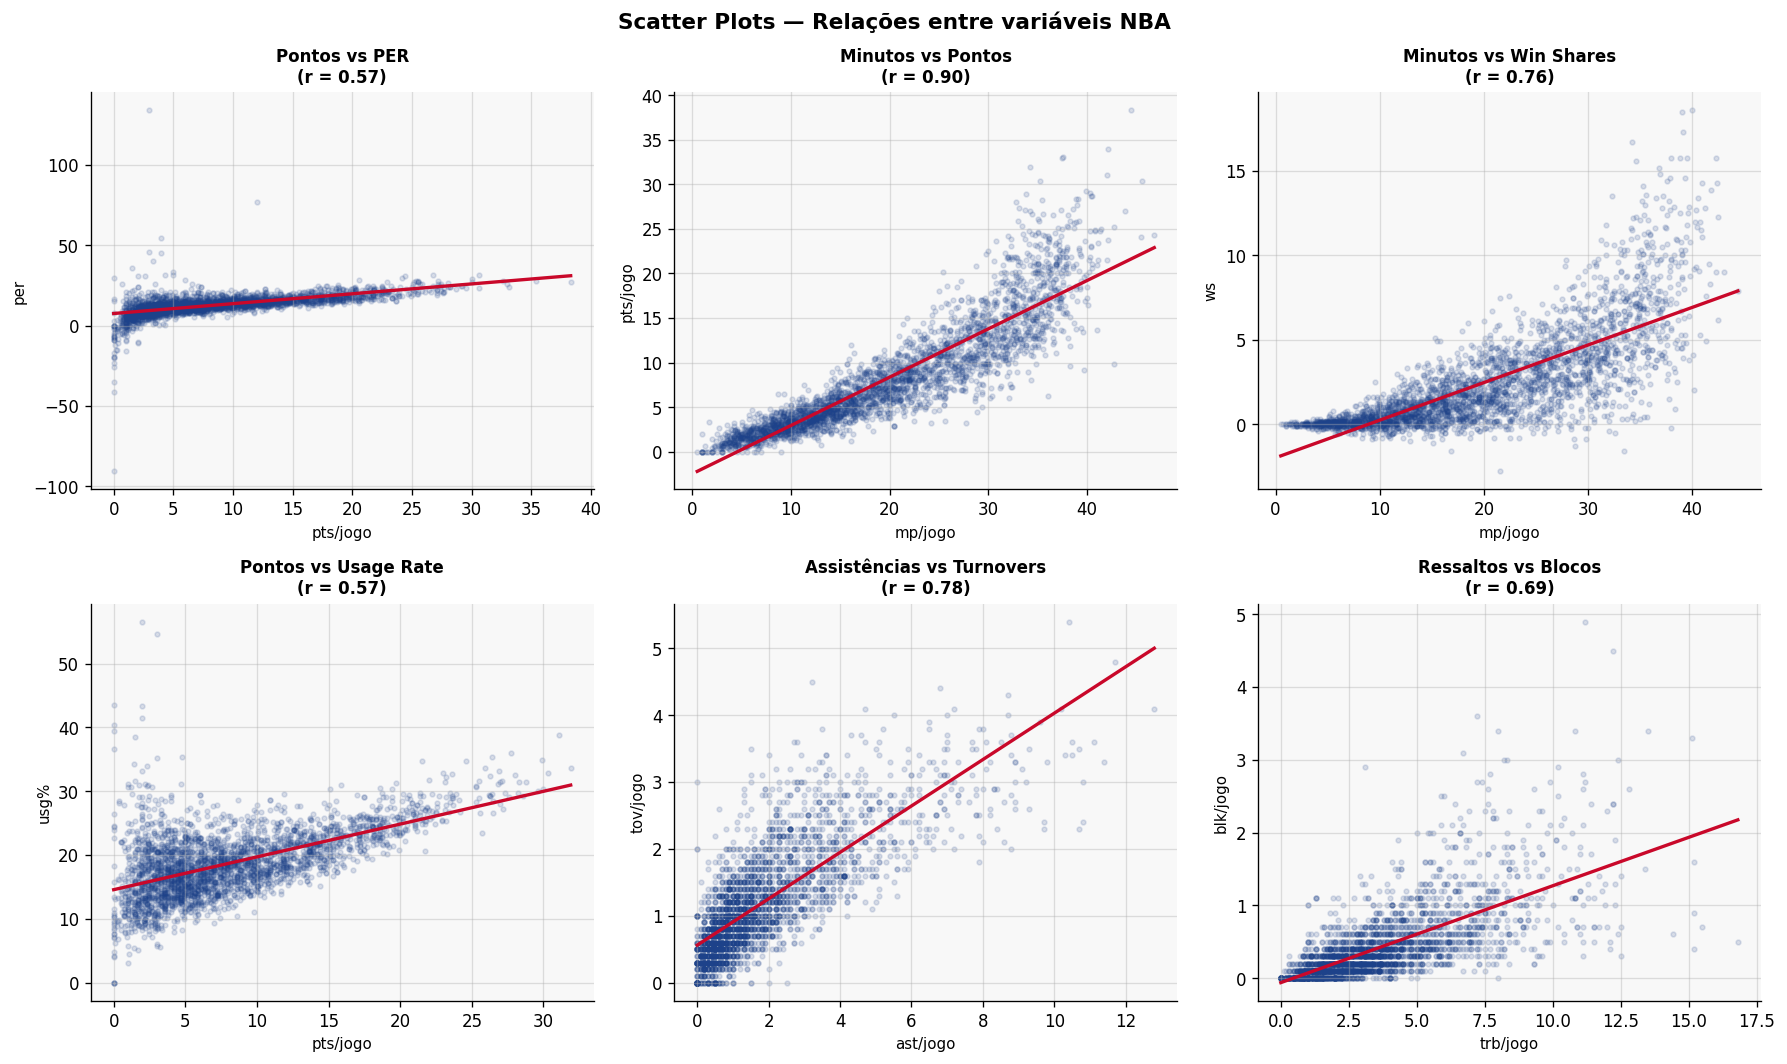

In [ ]:
# Scatter plots das correlações mais interessantes 

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

pares = [
    ('pts_per_game', 'per', 'Pontos vs PER'),
    ('mp_per_game', 'pts_per_game', 'Minutos vs Pontos'),
    ('mp_per_game', 'ws', 'Minutos vs Win Shares'),
    ('pts_per_game', 'usg_percent', 'Pontos vs Usage Rate'),
    ('ast_per_game', 'tov_per_game', 'Assistências vs Turnovers'),
    ('trb_per_game', 'blk_per_game', 'Ressaltos vs Blocos'),
]

for ax, (x, y, titulo) in zip(axes, pares):
    sample = df[[x, y]].dropna().sample(min(3000, len(df)), random_state=42)
    r = sample[x].corr(sample[y])

    ax.scatter(sample[x], sample[y], alpha=0.15, s=8, color='#1D428A')
    
    z = np.polyfit(sample[x], sample[y], 1)
    p = np.poly1d(z)
    x_line = np.linspace(sample[x].min(), sample[x].max(), 100)
    ax.plot(x_line, p(x_line), color='#C9082A', linewidth=2)

    ax.set_title(f'{titulo}\n(r = {r:.2f})', fontweight='bold', fontsize=10)
    ax.set_xlabel(x.replace('_per_game', '/jogo').replace('_percent', '%'), fontsize=9)
    ax.set_ylabel(y.replace('_per_game', '/jogo').replace('_percent', '%'), fontsize=9)

plt.suptitle('Scatter Plots — Relações entre variáveis NBA', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}02_scatter_correlacoes.png', bbox_inches='tight')
plt.show()

---
## Tabelas Resumo por Posição

Agrupamos os jogadores pelas suas posições para comparar os perfis estatísticos típicos de cada uma:
- PG (Point Guard) — base, responsável pela organização do jogo
- SG (Shooting Guard) — escolta, foco ofensivo
- SF (Small Forward) — extremo, perfil versátil
- PF (Power Forward) — poste 4, misto de interior e exterior
- C (Center) — pivô, domínio da zona interior

In [97]:
# Tabela resumo por posição 
pos_order = ['PG', 'SG', 'SF', 'PF', 'C']
df_pos = df[df['pos'].isin(pos_order)].copy()

resumo_pos = df_pos.groupby('pos')[STATS_ALL].mean().round(2)
resumo_pos = resumo_pos.reindex(pos_order)  # Ordenar pela posição no campo

print(f"Registos por posição:")
print(df_pos['pos'].value_counts().reindex(pos_order).to_string())
print(f"\nMédias por posição:")

# Highlight do valor máximo por coluna
resumo_pos.style \
    .highlight_max(axis=0, color='#1D428A', props='color: white; font-weight: bold') \
    .highlight_min(axis=0, color='#f8d7da', props='color: #721c24') \
    .format(precision=2) \
    .set_caption('Médias por posição — azul = máximo, rosa = mínimo')

Registos por posição:
pos
PG    5895
SG    6403
SF    5906
PF    6269
C     5951

Médias por posição:


,pts_per_game,ast_per_game,trb_per_game,stl_per_game,blk_per_game,tov_per_game,mp_per_game,fg_percent,ft_percent,per,ws,bpm,vorp,ts_percent,usg_percent
pos,,,,,,,,,,,,,,,
PG,8.57,3.71,2.26,0.87,0.15,1.52,21.21,0.41,0.77,12.70,2.46,-1.36,0.69,0.50,19.28
SG,9.11,2.07,2.47,0.74,0.21,1.20,20.67,0.42,0.77,11.99,2.24,-1.80,0.53,0.50,19.87
SF,8.90,1.55,3.57,0.69,0.33,1.15,20.74,0.43,0.74,12.28,2.48,-1.66,0.57,0.51,18.85
PF,8.15,1.24,4.88,0.56,0.51,1.13,19.86,0.45,0.70,13.01,2.63,-1.91,0.48,0.51,18.22
C,7.47,1.07,5.38,0.46,0.83,1.11,18.79,0.48,0.66,13.53,2.81,-2.10,0.49,0.52,17.32


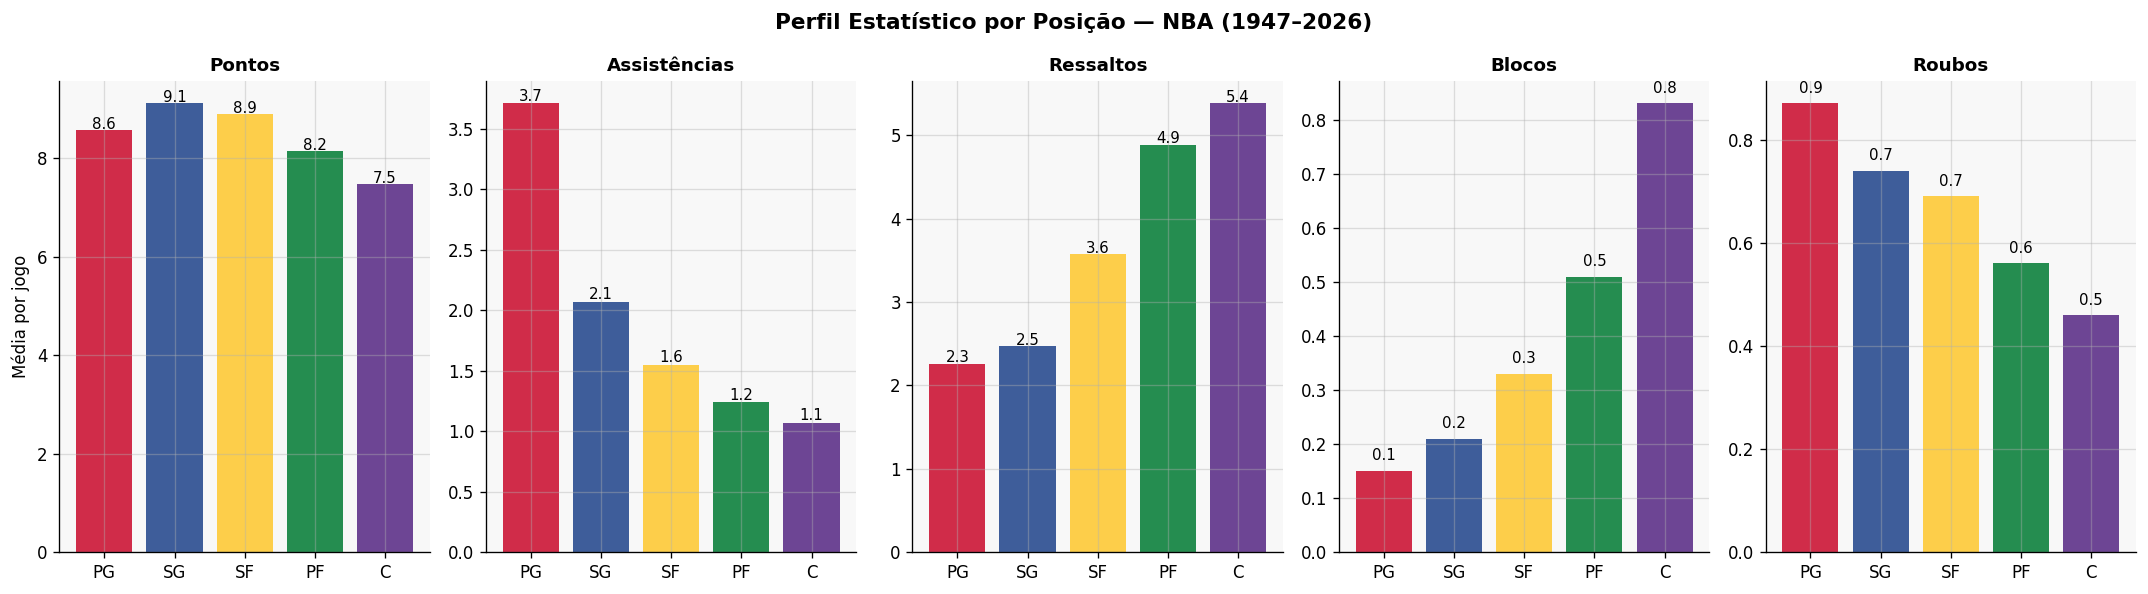

In [98]:
# Gráfico de barras agrupadas por posição 
stats_plot = ['pts_per_game', 'ast_per_game', 'trb_per_game', 'blk_per_game', 'stl_per_game']
labels = ['Pontos', 'Assistências', 'Ressaltos', 'Blocos', 'Roubos']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, stat, label in zip(axes, stats_plot, labels):
    valores = [resumo_pos.loc[p, stat] for p in pos_order]
    bars = ax.bar(pos_order, valores, color=PALETTE, alpha=0.85)
    ax.set_title(label, fontweight='bold', fontsize=11)
    ax.set_ylabel('Média por jogo' if ax == axes[0] else '')
    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f'{val:.1f}', ha='center', fontsize=9)

plt.suptitle('Perfil Estatístico por Posição — NBA (1947–2026)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}02_stats_por_posicao.png', bbox_inches='tight')
plt.show()

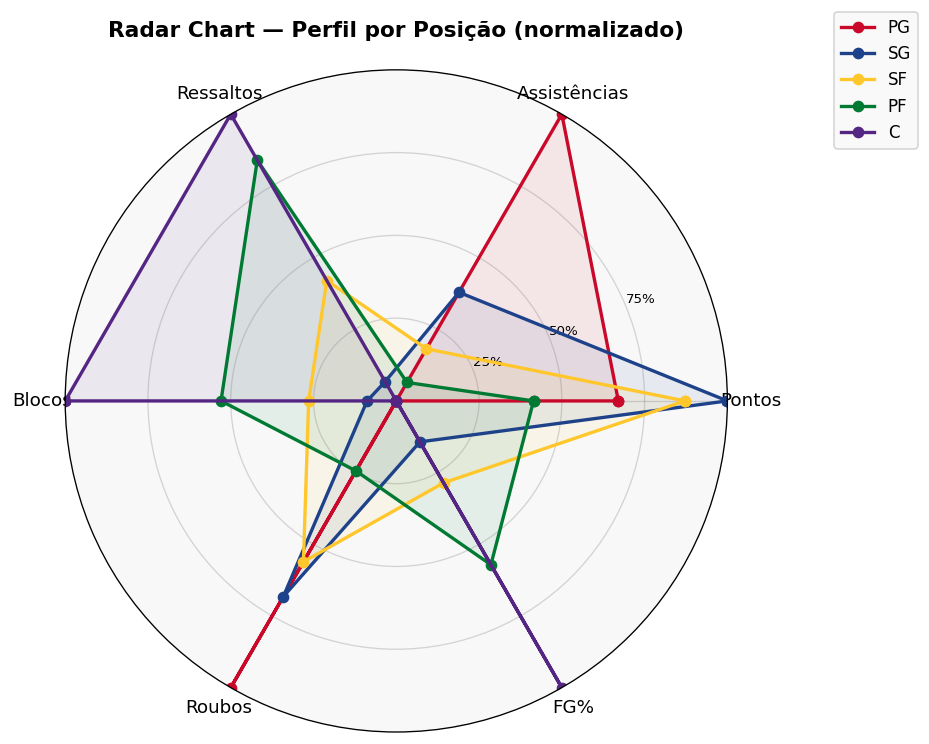

In [ ]:
# Radar chart — mostra o perfil de cada posição em todas as dimensões ao mesmo tempo
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

stats_radar = ['pts_per_game', 'ast_per_game', 'trb_per_game', 'blk_per_game', 'stl_per_game', 'fg_percent']
labels_radar = ['Pontos', 'Assistências', 'Ressaltos', 'Blocos', 'Roubos', 'FG%']

# Normalizar entre 0 e 1 para termos uma comparação justa
radar_data = resumo_pos[stats_radar].copy()
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

N = len(stats_radar)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1] 

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, pos in enumerate(pos_order):
    values = radar_norm.loc[pos].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=pos, color=PALETTE[i])
    ax.fill(angles, values, alpha=0.08, color=PALETTE[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75])
ax.set_yticklabels(['25%', '50%', '75%'], fontsize=8)
ax.set_title('Radar Chart — Perfil por Posição (normalizado)', fontweight='bold', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax.grid(color='gray', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}02_radar_posicoes.png', bbox_inches='tight')
plt.show()

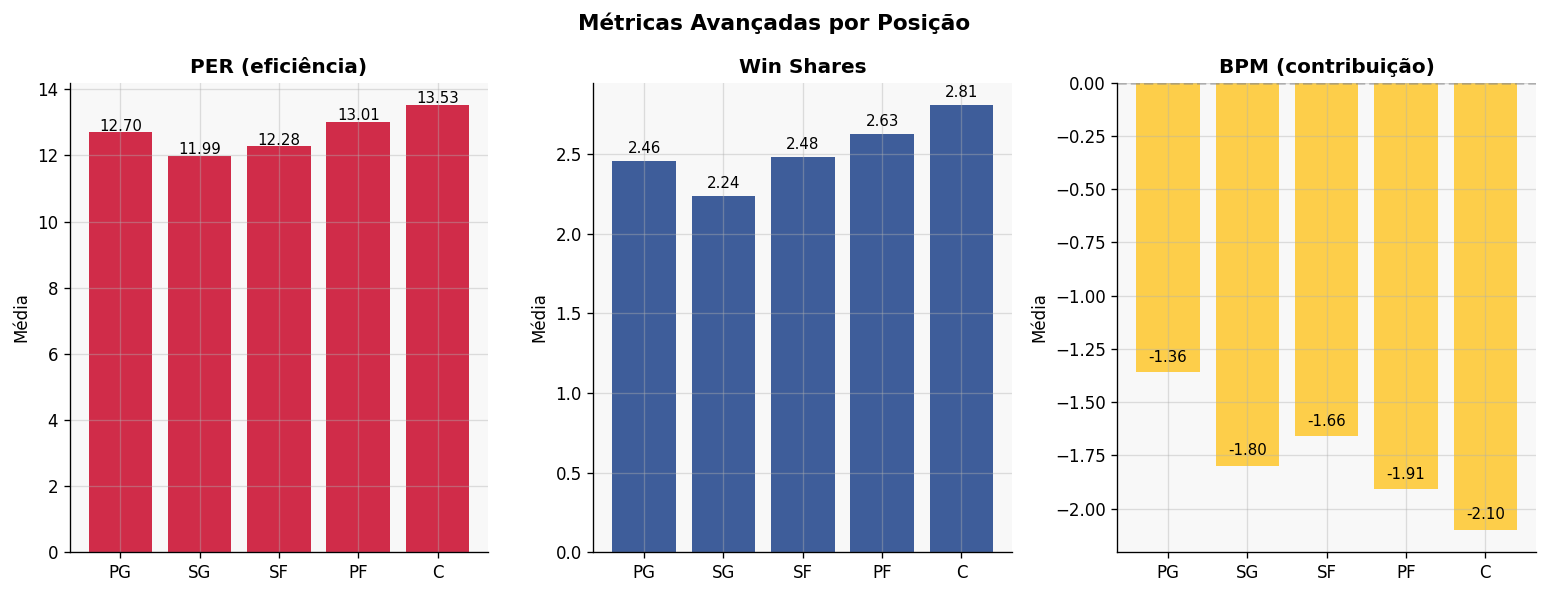

BPM médio por posição — só jogadores com 20+ minutos/jogo:
pos
PG    0.38
SG   -0.14
SF   -0.00
PF   -0.06
C     0.37
Name: bpm, dtype: float64

BPM médio por posição — todos os jogadores:
pos
PG   -1.36
SG   -1.80
SF   -1.66
PF   -1.91
C    -2.10
Name: bpm, dtype: float64
Distribuição de jogadores por nível de BPM (titulares):

  MVP Level           :   131 épocas (0.9%)
  Superstar           :   408 épocas (2.8%)
  Starter sólido      : 1,981 épocas (13.5%)
  Rotação útil        : 3,768 épocas (25.7%)
  Abaixo da média     : 8,387 épocas (57.2%)

Top 15 — Épocas MVP Level (BPM >= 8.0):
--------------------------------------------------
  Nikola Jokić              2026  BPM=14.9  pts=28.7  ws=10.7
  Nikola Jokić              2022  BPM=13.7  pts=27.1  ws=15.2
  Nikola Jokić              2025  BPM=13.3  pts=29.6  ws=16.4
  LeBron James              2009  BPM=13.2  pts=28.4  ws=20.3
  Nikola Jokić              2024  BPM=13.2  pts=26.4  ws=17.0
  Michael Jordan            1988  BPM=13.0  

In [100]:
# Métricas avançadas por posição 
adv_pos = df_pos.groupby('pos')[STATS_ADV].mean().round(2).reindex(pos_order)

fig, axes = plt.subplots(1, 3, figsize=(13, 5))

for ax, stat, titulo, cor in zip(
    axes,
    ['per', 'ws', 'bpm'],
    ['PER (eficiência)', 'Win Shares', 'BPM (contribuição)'],
    [PALETTE[0], PALETTE[1], PALETTE[2]]
):
    valores = adv_pos[stat].values
    bars = ax.bar(pos_order, valores, color=cor, alpha=0.85)
    ax.set_title(titulo, fontweight='bold')
    ax.set_ylabel('Média')
    if stat == 'bpm':
        ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.05,
                f'{val:.2f}', ha='center', fontsize=9)

plt.suptitle('Métricas Avançadas por Posição', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}02_adv_por_posicao.png', bbox_inches='tight')
plt.show()

#Comparação de BPM médio por posição entre titulares e todos os jogadores

# BPM médio por posição — só titulares (mais de 20 minutos por jogo)
titulares = df[df['mp_per_game'] >= 20]
print("BPM médio por posição — só jogadores com 20+ minutos/jogo:")
print(titulares.groupby('pos')['bpm'].mean().round(2).reindex(pos_order))

print("\nBPM médio por posição — todos os jogadores:")
print(df_pos.groupby('pos')['bpm'].mean().round(2).reindex(pos_order))

# Classificação por nível de BPM
def bpm_level(bpm):
    if bpm >= 8.0:   
        return 'MVP Level'
    if bpm >= 5.0:   
        return 'Superstar'
    if bpm >= 2.0:   
        return 'Starter sólido'
    if bpm >= 0.0:   
        return 'Rotação útil'
    return                  'Abaixo da média'

# Aplicar só a titulares
titulares = df[df['mp_per_game'] >= 20].copy()
titulares['bpm_level'] = titulares['bpm'].apply(bpm_level)

# Contagem por nível
print("\nDistribuição de jogadores por nível de BPM (titulares):\n")
counts = titulares['bpm_level'].value_counts()
order  = ['MVP Level', 'Superstar', 'Starter sólido', 'Rotação útil', 'Abaixo da média']
for nivel in order:
    n   = counts.get(nivel, 0)
    pct = n / len(titulares) * 100
    print(f"  {nivel:<20}: {n:>5,} épocas ({pct:.1f}%)")

# Top 15 MVP Level — os melhores da história
print("\nTop 15 — Épocas MVP Level (BPM >= 8.0):")
mvp_level = titulares[titulares['bpm'] >= 8.0] \
    .nlargest(15, 'bpm')[['player', 'season', 'bpm', 'pts_per_game', 'ws']]
for _, row in mvp_level.iterrows():
    print(f"  {row['player']} {int(row['season'])}  "
          f"BPM={row['bpm']:.1f}  pts={row['pts_per_game']:.1f}  ws={row['ws']:.1f}")

# Top 15 Superstar Level
print("\nTop 15 — Épocas Superstar Level (BPM entre 5.0 e 8.0):")
superstar = titulares[(titulares['bpm'] >= 5.0) & (titulares['bpm'] < 8.0)] \
    .nlargest(15, 'bpm')[['player', 'season', 'bpm', 'pts_per_game', 'ws']]
for _, row in superstar.iterrows():
    print(f"  {row['player']} {int(row['season'])}  "
          f"BPM={row['bpm']:.1f}  pts={row['pts_per_game']:.1f}  ws={row['ws']:.1f}")

---
## Tabelas Resumo por Era

O jogo da NBA evoluiu significativamente ao longo de 79 épocas. Agrupamos os dados por década para identificar tendências históricas:
- Como evoluiu a pontuação média ao longo do tempo?
- Quando é que os 3 pontos se tornaram dominantes?
- O jogo ficou mais rápido ou mais lento?
- Como evoluiu a eficiência ofensiva?

### Eras definidas
- BAA/Early NBA (1947–1959) — fundação da liga, regras primitivas
- Era Wilt/Russell (1960–1969) — domínio dos centros, pontuações absurdas
- Era ABA/Fusão (1970–1979) — introdução de novos estilos de jogo  
- Era Magic/Bird (1980–1989) — introdução da linha de 3 pontos em 1980
- Era Jordan (1990–1999) — apogeu defensivo, regras anti-físico
- Era Shaq/Kobe (2000–2009) — domínio dos interiores e transição
- Era Analytics (2010–2019) — revolução dos 3 pontos e pace
- Era Moderna (2020–2026) — pace máximo, shooting avançado

In [101]:
# Criar coluna de era
def classificar_era(season):
    if season < 1960: return '1947-59 BAA/Early NBA'
    if season < 1970: return '1960-69 Wilt/Russell'
    if season < 1980: return '1970-79 ABA/Fusão'
    if season < 1990: return '1980-89 Magic/Bird'
    if season < 2000: return '1990-99 Jordan'
    if season < 2010: return '2000-09 Shaq/Kobe'
    if season < 2020: return '2010-19 Analytics'
    return                    '2020-26 Moderna'

df['era'] = df['season'].apply(classificar_era)

# Ordem cronológica das eras
ERA_ORDER = [
    '1947-59 BAA/Early NBA',
    '1960-69 Wilt/Russell',
    '1970-79 ABA/Fusão',
    '1980-89 Magic/Bird',
    '1990-99 Jordan',
    '2000-09 Shaq/Kobe',
    '2010-19 Analytics',
    '2020-26 Moderna'
]

print("Registos por era:")
print(df['era'].value_counts().reindex(ERA_ORDER).to_string())

Registos por era:
era
1947-59 BAA/Early NBA    1506
1960-69 Wilt/Russell     1407
1970-79 ABA/Fusão        2817
1980-89 Magic/Bird       3805
1990-99 Jordan           4903
2000-09 Shaq/Kobe        5436
2010-19 Analytics        6129
2020-26 Moderna          4984


In [102]:
# Tabela resumo por era
stats_era = ['pts_per_game', 'ast_per_game', 'trb_per_game', 'fg_percent', 'ft_percent', 'mp_per_game']

resumo_era = df.groupby('era')[stats_era].mean().round(2)
resumo_era = resumo_era.reindex(ERA_ORDER)

print("Médias por era histórica:\n")
resumo_era.style \
    .highlight_max(axis=0, color='#1D428A', props='color: white; font-weight: bold') \
    .highlight_min(axis=0, color='#f8d7da', props='color: #721c24') \
    .format(precision=2) \
    .set_caption('Evolução das estatísticas ao longo das eras NBA')

Médias por era histórica:



,pts_per_game,ast_per_game,trb_per_game,fg_percent,ft_percent,mp_per_game
era,,,,,,
1947-59 BAA/Early NBA,7.87,1.88,4.67,0.34,0.70,22.48
1960-69 Wilt/Russell,10.32,2.05,5.45,0.41,0.69,22.24
1970-79 ABA/Fusão,9.49,2.15,4.35,0.44,0.73,21.66
1980-89 Magic/Bird,8.96,2.14,3.65,0.46,0.73,20.49
1990-99 Jordan,8.06,1.89,3.47,0.44,0.72,19.98
2000-09 Shaq/Kobe,7.76,1.75,3.46,0.43,0.72,20.14
2010-19 Analytics,7.94,1.76,3.42,0.44,0.73,19.62
2020-26 Moderna,8.46,1.96,3.45,0.45,0.75,19.01


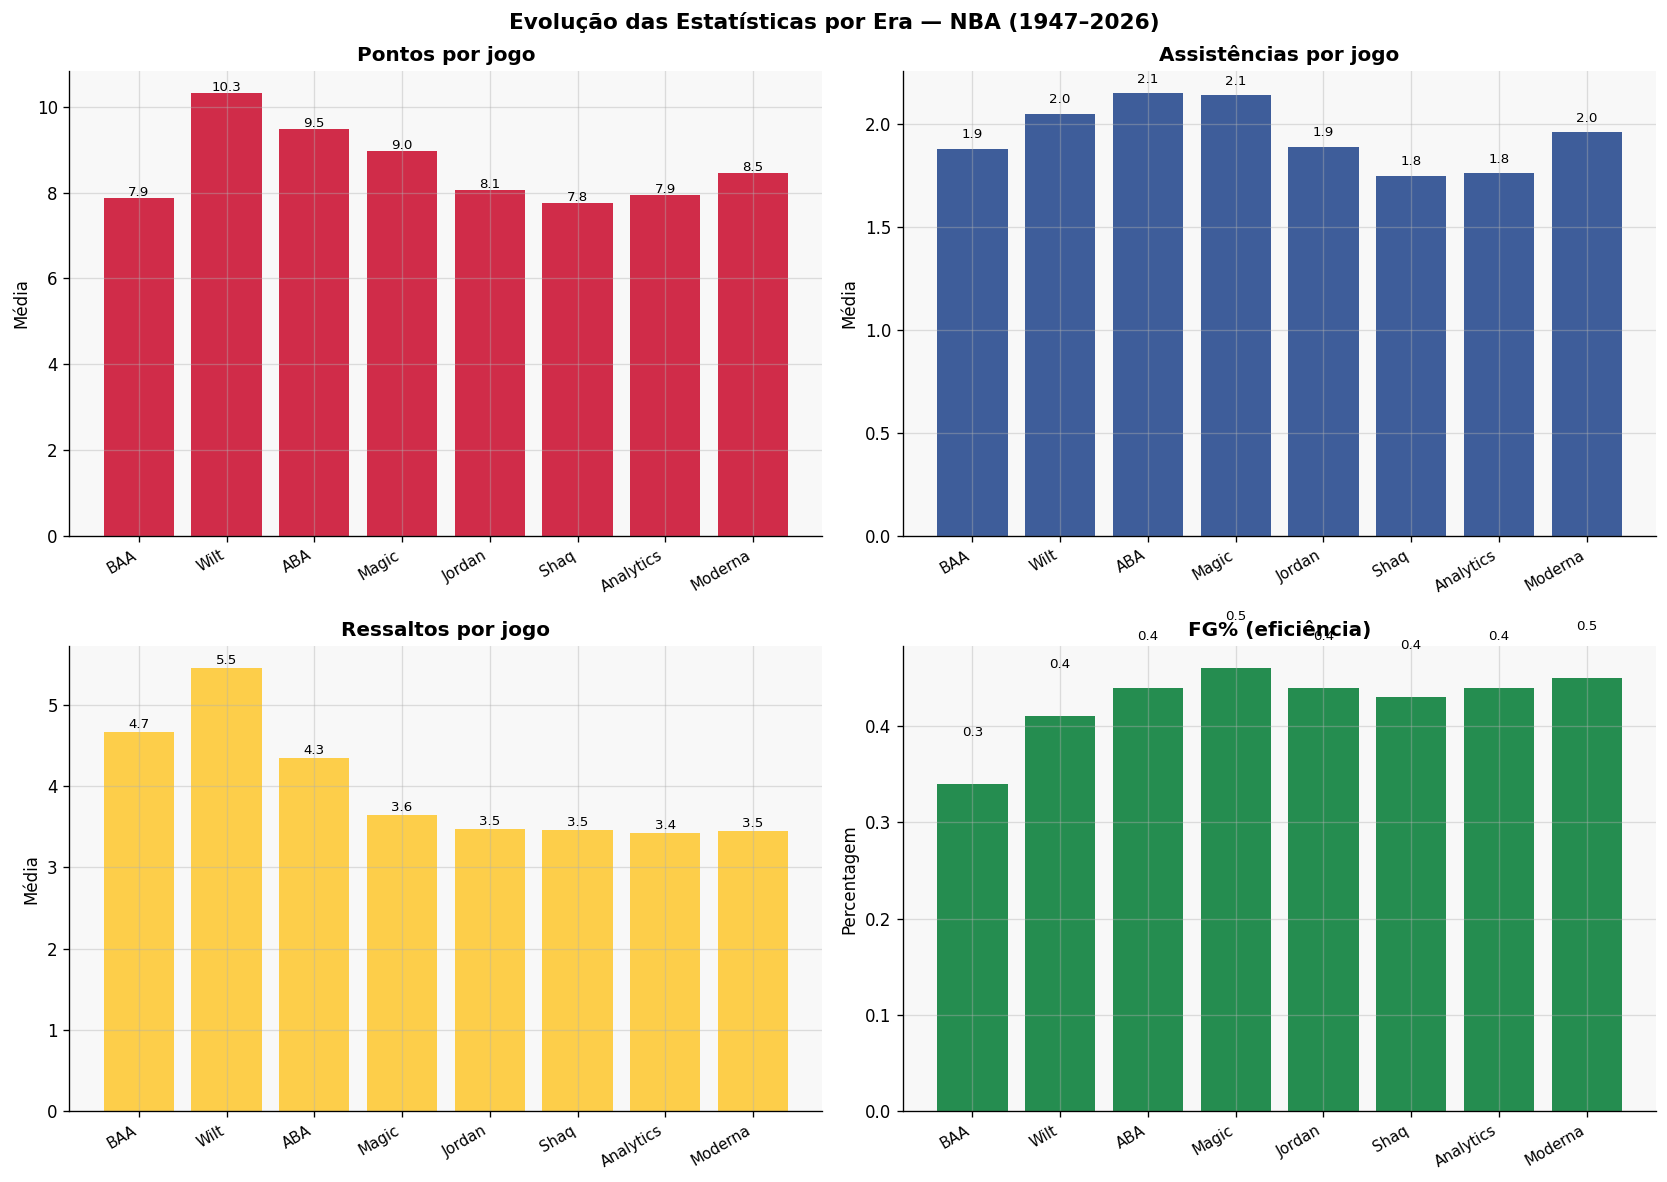

In [103]:
# Evolução da pontuação e assistências por era
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

eras_curtas = ['BAA', 'Wilt', 'ABA', 'Magic', 'Jordan', 'Shaq', 'Analytics', 'Moderna']

def plot_era(ax, stat, titulo, cor, ylabel):
    valores = resumo_era[stat].values
    bars = ax.bar(range(len(ERA_ORDER)), valores, color=cor, alpha=0.85)
    ax.set_xticks(range(len(ERA_ORDER)))
    ax.set_xticklabels(eras_curtas, rotation=30, ha='right', fontsize=9)
    ax.set_title(titulo, fontweight='bold')
    ax.set_ylabel(ylabel)
    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.05,
                f'{val:.1f}', ha='center', fontsize=8)

plot_era(axes[0,0], 'pts_per_game', 'Pontos por jogo', PALETTE[0], 'Média')
plot_era(axes[0,1], 'ast_per_game', 'Assistências por jogo', PALETTE[1], 'Média')
plot_era(axes[1,0], 'trb_per_game', 'Ressaltos por jogo', PALETTE[2], 'Média')
plot_era(axes[1,1], 'fg_percent', 'FG% (eficiência)', PALETTE[3], 'Percentagem')

plt.suptitle('Evolução das Estatísticas por Era — NBA (1947–2026)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}02_evolucao_por_era.png', bbox_inches='tight')
plt.show()

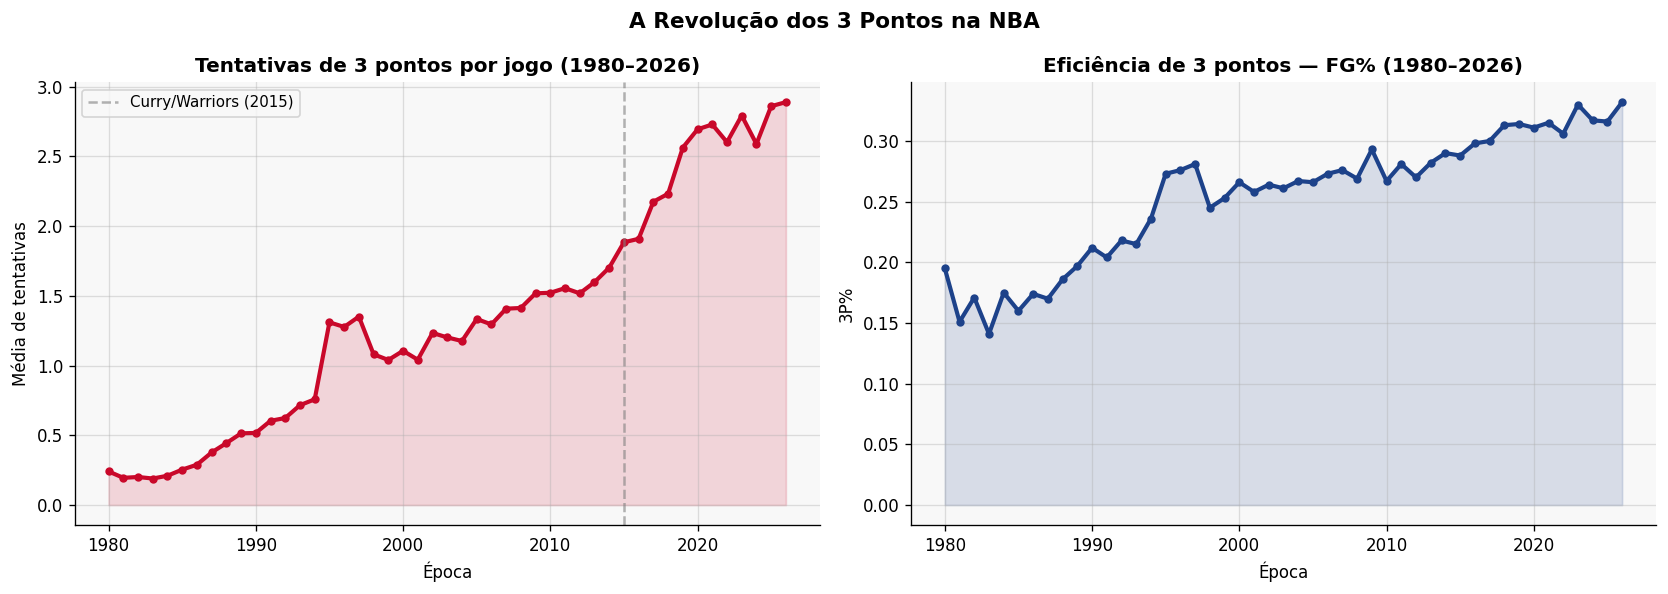

In [104]:
# Evolução dos 3 pontos por era 
# A linha dos 3 pontos foi introduzida em 1980 

df_3pts = df[df['season'] >= 1980].copy()

# Média de tentativas e % de 3 pontos por época
evolucao_3pts = df_3pts.groupby('season')[['x3pa_per_game', 'x3p_percent']].mean().round(3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tentativas de 3 pontos por jogo
axes[0].plot(evolucao_3pts.index, evolucao_3pts['x3pa_per_game'], color=PALETTE[0], linewidth=2.5, marker='o', markersize=4)
axes[0].fill_between(evolucao_3pts.index, evolucao_3pts['x3pa_per_game'], alpha=0.15, color=PALETTE[0])
axes[0].set_title('Tentativas de 3 pontos por jogo (1980–2026)', fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Média de tentativas')
axes[0].axvline(x=2015, color='gray', linestyle='--', alpha=0.6, label='Curry/Warriors (2015)')
axes[0].legend(fontsize=9)

# Eficiência de 3 pontos por época
axes[1].plot(evolucao_3pts.index, evolucao_3pts['x3p_percent'], color=PALETTE[1], linewidth=2.5, marker='o', markersize=4)
axes[1].fill_between(evolucao_3pts.index, evolucao_3pts['x3p_percent'], alpha=0.15, color=PALETTE[1])
axes[1].set_title('Eficiência de 3 pontos — FG% (1980–2026)', fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('3P%')

plt.suptitle('A Revolução dos 3 Pontos na NBA', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}02_revolucao_3pts.png', bbox_inches='tight')
plt.show()

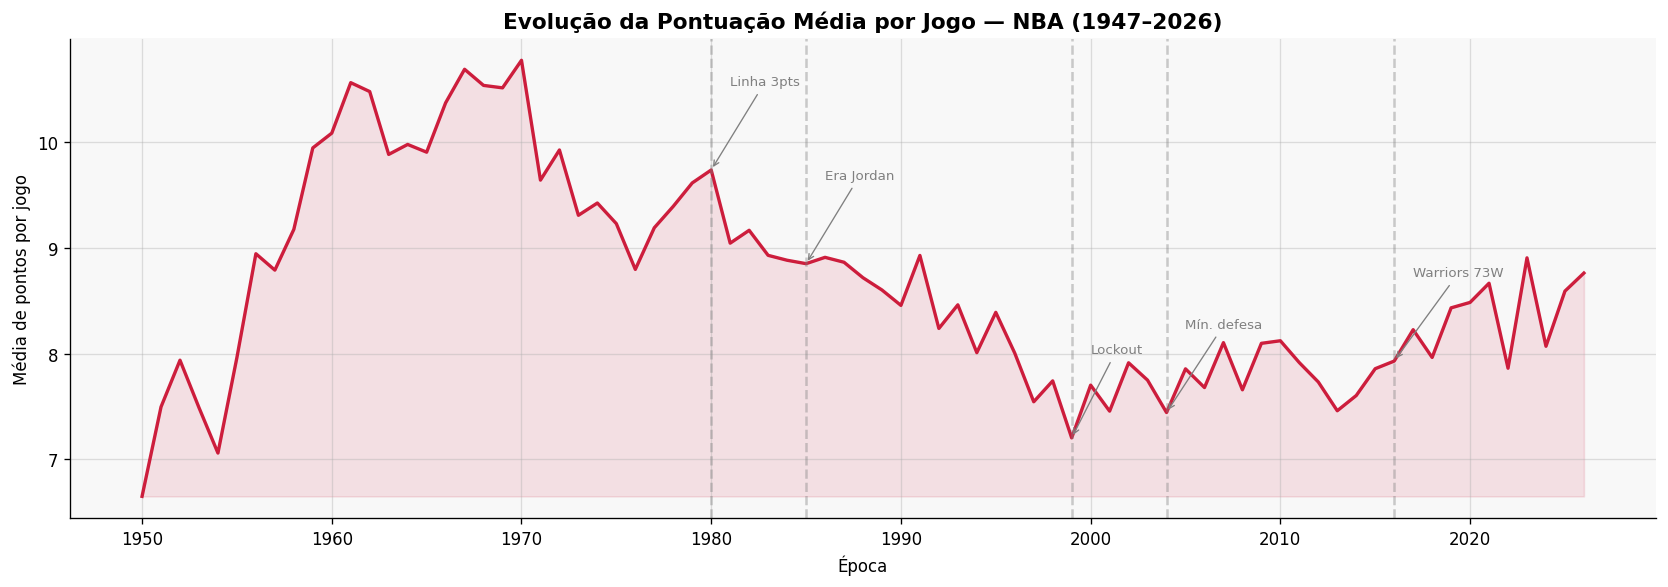

In [105]:
# Linha temporal — evolução dos pontos por época
# Ver a evolução ano a ano em vez de por era
pts_por_epoca = df.groupby('season')['pts_per_game'].mean()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(pts_por_epoca.index, pts_por_epoca.values, color=PALETTE[0], linewidth=2, alpha=0.9)
ax.fill_between(pts_por_epoca.index, pts_por_epoca.values, pts_por_epoca.min(), alpha=0.1, color=PALETTE[0])

eventos = {
    1980: 'Linha 3pts',
    1985: 'Era Jordan',
    1999: 'Lockout',
    2004: 'Mín. defesa',
    2016: 'Warriors 73W',
}
for ano, label in eventos.items():
    if ano in pts_por_epoca.index:
        val = pts_por_epoca[ano]
        ax.axvline(x=ano, color='gray', linestyle='--', alpha=0.4)
        ax.annotate(label, xy=(ano, val),
                    xytext=(ano + 1, val + 0.8),
                    fontsize=8, color='gray',
                    arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

ax.set_title('Evolução da Pontuação Média por Jogo — NBA (1947–2026)', fontweight='bold', fontsize=13)
ax.set_xlabel('Época')
ax.set_ylabel('Média de pontos por jogo')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}02_evolucao_pontos_timeline.png', bbox_inches='tight')
plt.show()

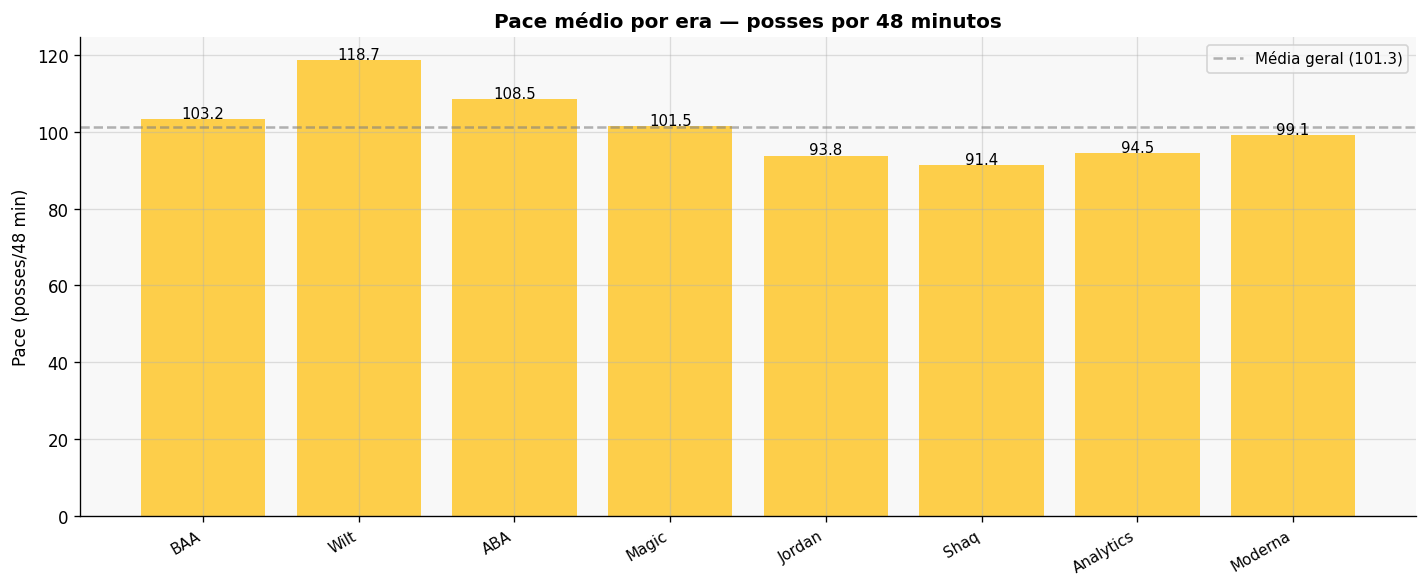


Interpretação:
  Era mais rápida : 1960-69 Wilt/Russell (118.7)
  Era mais lenta  : 2000-09 Shaq/Kobe (91.4)
  Diferença       : 27.3 posses/jogo


In [106]:
# Pace por era
# O pace mede o ritmo de jogo — posses por 48 minutos
teams = pd.read_csv(f'{OUTPUT_DIR}team_summaries.csv', low_memory=False)
teams['era'] = teams['season'].apply(classificar_era)

pace_por_era = teams.groupby('era')['pace'].mean().round(1).reindex(ERA_ORDER)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(ERA_ORDER)), pace_por_era.values, color=PALETTE[2], alpha=0.85)
ax.set_xticks(range(len(ERA_ORDER)))
ax.set_xticklabels(eras_curtas, rotation=30, ha='right', fontsize=9)
ax.set_title('Pace médio por era — posses por 48 minutos', fontweight='bold', fontsize=12)
ax.set_ylabel('Pace (posses/48 min)')
ax.axhline(y=pace_por_era.mean(), color='gray', linestyle='--', alpha=0.6, label=f'Média geral ({pace_por_era.mean():.1f})')
ax.legend(fontsize=9)
for bar, val in zip(bars, pace_por_era.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}02_pace_por_era.png', bbox_inches='tight')
plt.show()
print("\nInterpretação:")
print(f"  Era mais rápida: {pace_por_era.idxmax()} ({pace_por_era.max():.1f})")
print(f"  Era mais lenta: {pace_por_era.idxmin()} ({pace_por_era.min():.1f})")
print(f"  Diferença: {pace_por_era.max() - pace_por_era.min():.1f} posses/jogo")

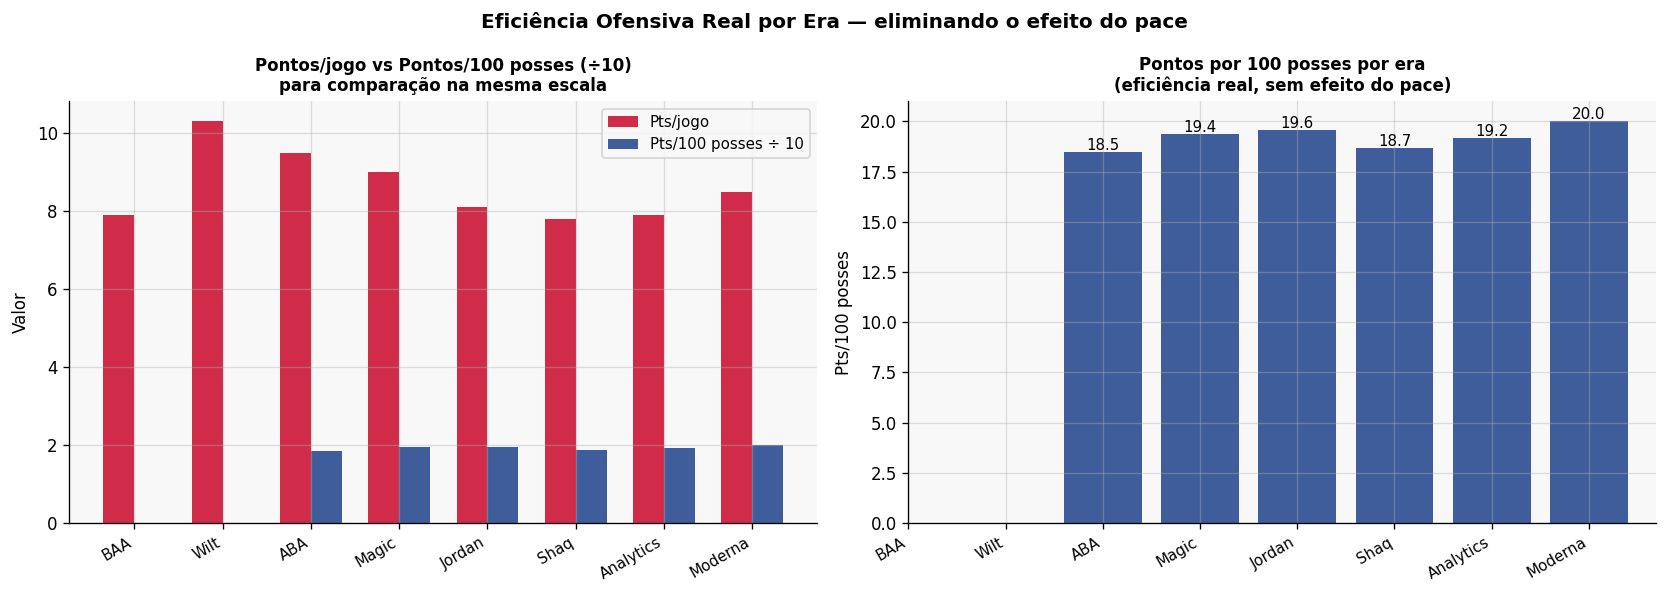


Comparação pontos/jogo vs pontos/100 posses:
-------------------------------------------------------
  BAA/Early   : 7.9 pts/jogo  |  nan pts/100 posses
  Wilt/Russell: 10.3 pts/jogo  |  nan pts/100 posses
  ABA/Fusão   : 9.5 pts/jogo  |  18.5 pts/100 posses
  Magic/Bird  : 9.0 pts/jogo  |  19.4 pts/100 posses
  Jordan      : 8.1 pts/jogo  |  19.6 pts/100 posses
  Shaq/Kobe   : 7.8 pts/jogo  |  18.7 pts/100 posses
  Analytics   : 7.9 pts/jogo  |  19.2 pts/100 posses
  Moderna     : 8.5 pts/jogo  |  20.0 pts/100 posses


In [107]:
# Pontos por 100 posses por era
# Esta métrica elimina o efeito do pace — compara eficiência real entre eras
per100 = pd.read_csv(f'{OUTPUT_DIR}../data/Per 100 Poss.csv', low_memory=False)

# Filtrar só NBA e deduplicar
per100 = per100[per100['lg'] == 'NBA']
per100 = per100[~per100.duplicated(subset=['player_id', 'season'], keep=False) |
                per100['team'].isin(['2TM', '3TM'])]
per100['era'] = per100['season'].apply(classificar_era)

pts100_era = per100.groupby('era')['pts_per_100_poss'].mean().round(1).reindex(ERA_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pontos por jogo vs pontos por 100 posses
pts_jogo_era = df.groupby('era')['pts_per_game'].mean().round(1).reindex(ERA_ORDER)

x = range(len(ERA_ORDER))
width = 0.35

axes[0].bar([i - width/2 for i in x], pts_jogo_era.values, width, label='Pts/jogo', color=PALETTE[0], alpha=0.85)
axes[0].bar([i + width/2 for i in x], pts100_era.values / 10, width, label='Pts/100 posses ÷ 10', color=PALETTE[1], alpha=0.85)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(eras_curtas, rotation=30, ha='right', fontsize=9)
axes[0].set_title('Pontos/jogo vs Pontos/100 posses (÷10)\npara comparação na mesma escala', fontweight='bold', fontsize=10)
axes[0].legend(fontsize=9)
axes[0].set_ylabel('Valor')

# Só pontos por 100 posses
bars = axes[1].bar(range(len(ERA_ORDER)), pts100_era.values, color=PALETTE[1], alpha=0.85)
axes[1].set_xticks(range(len(ERA_ORDER)))
axes[1].set_xticklabels(eras_curtas, rotation=30, ha='right', fontsize=9)
axes[1].set_title('Pontos por 100 posses por era\n(eficiência real, sem efeito do pace)', fontweight='bold', fontsize=10)
axes[1].set_ylabel('Pts/100 posses')
for bar, val in zip(bars, pts100_era.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'{val:.1f}', ha='center', fontsize=9)

plt.suptitle('Eficiência Ofensiva Real por Era — eliminando o efeito do pace', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}02_pts_100_posses_era.png', bbox_inches='tight')
plt.show()

print("\nComparação pontos/jogo vs pontos/100 posses:")
for era in ERA_ORDER:
    era_curta = era.split(' ')[1] if ' ' in era else era
    p_jogo = pts_jogo_era.get(era, 0)
    p_100  = pts100_era.get(era, 0)
    print(f"  {era_curta}: {p_jogo:.1f} pts/jogo | {p_100:.1f} pts/100 posses")


---
## Análise Crítica 

Esta secção documenta os principais pontos a ter em conta na interpretação dos resultados.

ANÁLISE CRÍTICA 

1. TENDÊNCIA CENTRAL
   • A única variável com assimetria significativa é pts_per_game
     (média 8.38 vs mediana 6.90) — um grupo pequeno de estrelas
     puxa a média para cima. As restantes são aproximadamente simétricas.
   • O BPM médio negativo em todas as posições é esperado — inclui
     reservas e rookies muito abaixo da referência de um titular.
     Filtrando jogadores com 20+ minutos, os valores sobem para ~0.

2. DISPERSÃO
   • Blocos (CV=119%) e assistências (CV=93%) são as estatísticas
     mais variáveis — habilidades muito específicas de poucos jogadores.
   • Percentagens de remate (CV~20%) são as mais uniformes —
     todos os jogadores NBA acertam entre 40-50% dos remates.
   • Os outliers históricos são dominados pelo Wilt Chamberlain
     (pontos e ressaltos) e John Stockton (assistências) em
     épocas individuais. Na média de carreira, Jordan lidera
     os pontos (30.12 PPG).

3. CORRELAÇÕES
   • Correlações mais fortes: VORP/WS (0.906), mp/pts (0.892),
     ts%/fg% (0.879), BPM/PER (0.867).
   • VORP e Win Shares são quase redundantes — na Parte II
     usar apenas um como feature para evitar multicolinearidade.
   • Blocos e assistências têm correlação ~0 — habilidades
     completamente independentes, de posições diferentes.

4. ANÁLISE POR POSIÇÃO
   • Centros têm o PER (13.53) e Win Shares (2.81) mais altos
     apesar de marcarem menos — ressaltos e blocos são muito
     valorizados nestas métricas.
   • Bases são a posição menos negativa no BPM (-1.36) entre
     titulares — inteligência de jogo compensa atletismo.
   • Classificação por BPM confirma raridade da elite:
     só 0.9% das épocas de titulares atingem MVP Level (>=8.0).
     Jokić domina com 6 das top 15 épocas históricas.

5. EVOLUÇÃO HISTÓRICA
   • Pontuação: pico na era Wilt (10.3), mínimo na era Jordan
     (7.8 — defesa física intensa), recuperação na era moderna (8.5).
   • Revolução dos 3 pontos: de 0.2 tentativas/jogo em 1980
     para 2.9 em 2026 — mudança estrutural no jogo após 2015
     impulsionada pelos Warriors/Curry.
   • Eficiência (FG%) subiu de 0.30 para 0.50 ao longo de 79 anos —
     jogadores modernos são significativamente mais eficientes.
   • Pace: variação relevante entre eras explica diferenças de
     pontuação — pontos por 100 posses é a métrica mais justa
     para comparar eras diferentes.